<a href="https://colab.research.google.com/github/mbrinkl5/ECGR-4106---Introduction-to-Deep-Learning/blob/main/Homework_5_ResNet18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%load_ext tensorboard

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms, datasets
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch.nn.functional as F
import matplotlib.pyplot as plt

import datetime
import os
import tensorflow as tf
import time

from tqdm import tqdm
from thop import profile

In [ ]:

from torchvision.transforms import v2

In [ ]:
!pip install torchsummary

In [ ]:
from torchsummary import summary

In [ ]:
!pip install thop

In [ ]:
!pip install torchinfo

In [ ]:
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # if using multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CIFAR-100 dataloader

In [ ]:
# Hyperparameters
image_size = 32
patch_size = 4
num_classes = 100
num_epochs = 10
batch_size = 64
learning_rate = 0.001
num_heads = 4
num_layers = 4
hidden_dim = 256
mlp_dim = 1024

In [ ]:
# Data preparation
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [ ]:
# CIFAR-100 dataset
train_dataset = torchvision.datasets.CIFAR100(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR100(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [ ]:
# Data loaders
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False
)

# **ResNet18**

In [ ]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        # First convolutional layer in the block
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        # Second convolutional layer in the block
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        # If stride is not 1 or in_channels are different, we need a shortcut connection
        if stride != 1 or in_channels != self.expansion * out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, self.expansion * out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * out_channels)
            )

    def forward(self, x):
        # Forward pass for the block
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)  # Add shortcut connection
        out = F.relu(out)
        return out

In [ ]:
class ResNet18(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet18, self).__init__()
        self.in_channels = 64  # Initial number of input channels

        # Initial convolutional layer before entering the residual blocks
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)  # Batch normalization after the initial convolution

        # Creating layers of blocks with increasing channel sizes
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        # Dropout layer added here after feature extraction
        self.dropout = nn.Dropout(p=0.3)

        # Final fully connected layer for classification
        self.linear = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        # Helper function to create a layer with specified blocks
        strides = [stride] + [1]*(num_blocks-1)  # First block could have a stride and the rest have stride of 1
        layers = []
        for stride in strides:
            layers.append(block(self.in_channels, out_channels, stride))
            self.in_channels = out_channels * block.expansion  # Update in_channels for the next block
        return nn.Sequential(*layers)

    def forward(self, x):
        # Forward pass through the initial convolution, batch norm, and ReLU activation
        out = F.relu(self.bn1(self.conv1(x)))
        # Forward pass through all the layers of blocks
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        # Global average pooling before the final layer
        out = F.avg_pool2d(out, 4)
        out = out.view(out.size(0), -1)  # Flatten the output for the fully connected layer
        # dropout before the final linear layer
        out = self.dropout(out)
        out = self.linear(out)  # Final classification layer
        return out

In [ ]:
model = ResNet18(BasicBlock, [2, 2, 2, 2], num_classes=100)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
summary(model, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,728
       BatchNorm2d-2           [-1, 64, 32, 32]             128
            Conv2d-3           [-1, 64, 32, 32]          36,864
       BatchNorm2d-4           [-1, 64, 32, 32]             128
            Conv2d-5           [-1, 64, 32, 32]          36,864
       BatchNorm2d-6           [-1, 64, 32, 32]             128
        BasicBlock-7           [-1, 64, 32, 32]               0
            Conv2d-8           [-1, 64, 32, 32]          36,864
       BatchNorm2d-9           [-1, 64, 32, 32]             128
           Conv2d-10           [-1, 64, 32, 32]          36,864
      BatchNorm2d-11           [-1, 64, 32, 32]             128
       BasicBlock-12           [-1, 64, 32, 32]               0
           Conv2d-13          [-1, 128, 16, 16]          73,728
      BatchNorm2d-14          [-1, 128,

In [ ]:
net = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)


In [ ]:
# Lists for storing loss values and validation accuracy
train_loss_list = []
val_loss_list = []
val_accuracy_list = []

In [ ]:
# Lists for storing loss values and validation accuracy
train_loss_list = []
val_loss_list = []
val_accuracy_list = []

In [ ]:
for epoch in range(num_epochs):  # loop over the dataset multiple times
    running_loss = 0.0
    net.train()  # Set the model to training mode
    for i, data in enumerate(train_loader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss_list.append(running_loss / len(train_loader))

    scheduler.step() # Call scheduler.step() after each epoch

    # Validation loop
    running_loss = 0.0
    correct = 0
    total = 0
    net.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        for data in test_loader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = net(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_loss_list.append(running_loss / len(test_loader))
    val_accuracy = 100 * correct / total
    val_accuracy_list.append(val_accuracy)

    print(f'Epoch {epoch + 1}, Training loss: {train_loss_list[-1]}, Validation loss: {val_loss_list[-1]}, Validation Accuracy: {val_accuracy}%')

Epoch 1, Training loss: 3.859349828242036, Validation loss: 3.421146531013926, Validation Accuracy: 18.42%
Epoch 2, Training loss: 3.12800518387114, Validation loss: 2.8401840370931444, Validation Accuracy: 28.45%
Epoch 3, Training loss: 2.642595886117052, Validation loss: 2.613524777114771, Validation Accuracy: 32.5%
Epoch 4, Training loss: 2.2835841921284374, Validation loss: 2.3814014416591376, Validation Accuracy: 37.69%
Epoch 5, Training loss: 1.9763584929658933, Validation loss: 2.082576932421156, Validation Accuracy: 44.25%
Epoch 6, Training loss: 1.698858869959936, Validation loss: 2.0519653399279165, Validation Accuracy: 45.09%
Epoch 7, Training loss: 1.4400455852603669, Validation loss: 2.0076780182540794, Validation Accuracy: 46.31%
Epoch 8, Training loss: 1.1792201158945517, Validation loss: 2.070746331457879, Validation Accuracy: 46.22%
Epoch 9, Training loss: 0.9128837229498207, Validation loss: 2.0802308844912583, Validation Accuracy: 46.21%
Epoch 10, Training loss: 0.67

In [ ]:
def evaluate(model, data_loader, criterion, device, phase='Validation'):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    inference_times = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            start_time = time.time()
            outputs = model(inputs)
            end_time = time.time()
            inference_times.append(end_time - start_time)

            loss = criterion(outputs, labels)
            running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = running_loss / len(data_loader)
    accuracy = 100 * correct / total
    avg_inference_time = sum(inference_times) / len(inference_times)

    print(f'{phase} Loss: {avg_loss:.4f}, {phase} Accuracy: {accuracy:.2f}%')
    print(f'Average Inference Time per Batch ({phase}): {avg_inference_time:.4f} seconds')
    return avg_loss, accuracy, avg_inference_time

In [ ]:
from thop import profile

# Training loop
def train():
    print("\nStarting training...")
    start_time_total = time.time()

    # Lists to store metrics for plotting
    epoch_train_losses = []
    epoch_val_losses = []
    epoch_val_accuracies = []

    # Number of parameters
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total trainable parameters: {total_params}")

    # FLOPs
    dummy_input = torch.randn(1, 3, image_size, image_size).to(device)
    macs, params = profile(model, inputs=(dummy_input,), verbose=False)
    print(f"Average FLOPs (MACs): {macs / 1e9:.2f} GFLOPS")

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for i, (images, labels) in enumerate(tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs} Training')):
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        epoch_train_losses.append(avg_train_loss)
        print(f"Epoch {epoch + 1} finished. Average training loss: {avg_train_loss:.4f}")

        # Validation after each epoch
        val_loss, val_accuracy, avg_inference_time = evaluate(model, test_loader, criterion, device, phase='Validation')
        epoch_val_losses.append(val_loss)
        epoch_val_accuracies.append(val_accuracy)

    end_time_total = time.time()
    print(f"\nTraining finished in {(end_time_total - start_time_total):.2f} seconds")
    print(f"Final Training Loss: {avg_train_loss:.4f}")

    return epoch_train_losses, epoch_val_losses, epoch_val_accuracies

In [ ]:
train_losses, val_losses, val_accuracies = train()


Starting training...
Total trainable parameters: 11220132
Average FLOPs (MACs): 0.56 GFLOPS


Epoch 1/10 Training: 100%|██████████| 782/782 [00:23<00:00, 33.33it/s]


Epoch 1 finished. Average training loss: 0.4625
Validation Loss: 2.2489, Validation Accuracy: 46.23%
Average Inference Time per Batch (Validation): 0.0031 seconds


Epoch 2/10 Training: 100%|██████████| 782/782 [00:22<00:00, 34.58it/s]


Epoch 2 finished. Average training loss: 0.2959
Validation Loss: 2.2809, Validation Accuracy: 46.04%
Average Inference Time per Batch (Validation): 0.0031 seconds


...

Epoch 8 finished. Average training loss: 0.0175
Validation Loss: 2.1690, Validation Accuracy: 50.51%
Average Inference Time per Batch (Validation): 0.0056 seconds


Epoch 9/10 Training: 100%|██████████| 782/782 [00:22<00:00, 34.58it/s]


Epoch 9 finished. Average training loss: 0.0142
Validation Loss: 2.1832, Validation Accuracy: 50.58%
Average Inference Time per Batch (Validation): 0.0031 seconds


Epoch 10/10 Training: 100%|██████████| 782/782 [00:22<00:00, 34.79it/s]


Epoch 10 finished. Average training loss: 0.0114
Validation Loss: 2.1929, Validation Accuracy: 50.40%
Average Inference Time per Batch (Validation): 0.0031 seconds

Training finished in 260.47 seconds
Final Training Loss: 0.0114


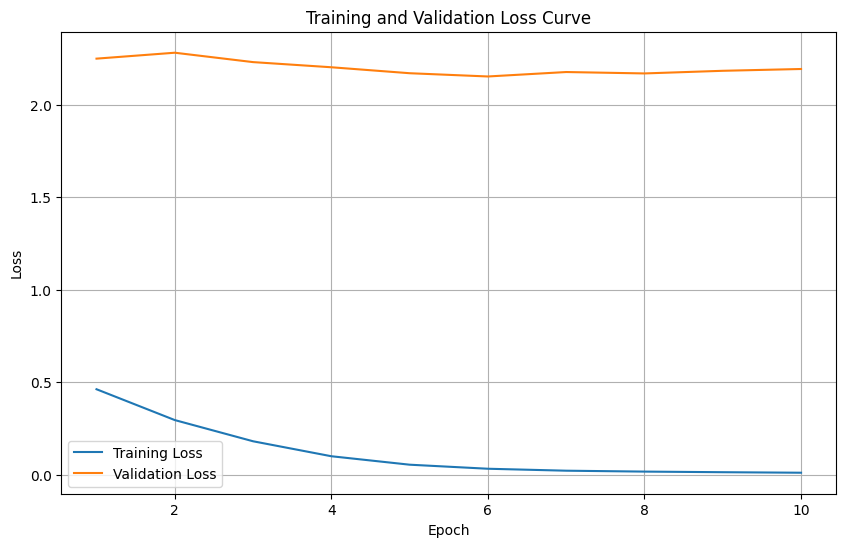

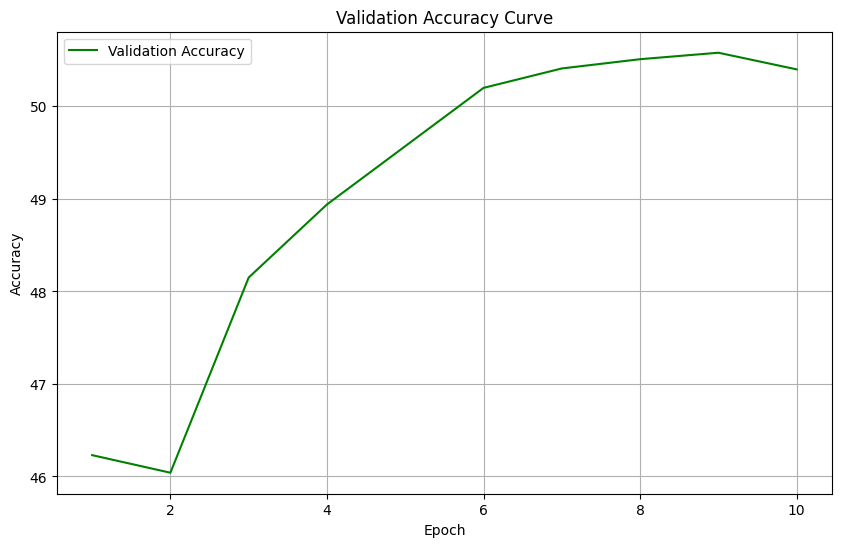

In [ ]:
import matplotlib.pyplot as plt

# Define epochs based on the length of the collected loss data
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, train_losses, label='Training Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Curve')
plt.legend()
plt.grid(True)
plt.show()